# 3. The rolling vine: how dependence evolves over time

**What you will do**

1. Fit a vine on a sliding window, day after day (`RollingVineModel`).
2. Look at what is stored for every date, and why the results are plain tables and not model objects.
3. Run the same thing one observation at a time, as a live system would, and check that it gives identical answers.
4. See how the window length changes the picture.

**Before you start:** notebooks 1 and 2. This notebook needs about two minutes (it fits roughly 150 vines) and writes a small
*demo run* to `data/results/demo/`, which notebooks 4 to 6 can use if you have not made the full 20-year run.

**The full run** is done by `python scripts/run_rolling.py` (about an hour on 4 cores; it can be stopped and resumed).
Everything below works on the last 600 days only so that it finishes quickly.

In [1]:
import os, warnings
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":      # notebooks run from the notebooks/ folder; the project root is one level up
    ROOT = ROOT.parent
os.chdir(ROOT)                    # all paths below are relative to the project folder
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.width", 140); pd.set_option("display.max_columns", 30)
print("working folder:", Path.cwd().name)

working folder: Quant_copula


In [2]:
from vine_risk.config import load_config
from vine_risk.pipeline import load_prices_and_returns
from vine_risk.rolling import RollingVineModel, results_to_frames, save_results

cfg = load_config("configs/default.yaml")
prices, returns = load_prices_and_returns(cfg)
recent = returns.iloc[-600:]
print(f"{len(recent)} days: {recent.index[0].date()} to {recent.index[-1].date()}")

600 days: 2024-05-13 to 2026-10-02


## 3.1 The model

Three settings define the experiment:

* `window`: how many days each fit sees (250 is about one trading year);
* `refit_frequency`: refit every day (`1`) or every *n*-th day. We use 5 here to save time. The other days simply
  keep the latest fit, and the model does *not* look into the future either way;
* `vine_kwargs`: options passed to `VineCopula`, such as the truncation level.

The fit for date *t* uses only the 250 returns ending on *t*. The rank transform is redone inside every window,
so nothing leaks from the future.

In [3]:
DEMO = Path("data/results/demo")
DEMO.mkdir(parents=True, exist_ok=True)

model = RollingVineModel(window=250, refit_frequency=5,
                         vine_kwargs=dict(truncation_level=3, tail_simulations=16384, seed=42))
print("fit positions (first 5):", [str(recent.index[p].date()) for p in model.refit_positions(len(recent))[:5]])

# n_jobs: windows are independent, so they can be fitted on several CPU cores at once.
# checkpoint: every result is written to this file as it completes, so an interrupted run can be resumed.
results = model.run(recent, n_jobs=4, checkpoint=DEMO / "checkpoint.jsonl")
print(len(results), "fits |", results[0].timestamp, "to", results[-1].timestamp,
      "| failed:", sum(r.status != "ok" for r in results))

fit positions (first 5): ['2025-05-12', '2025-05-19', '2025-05-27', '2025-06-03', '2025-06-10']
71 fits | 2025-05-12 to 2026-10-02 | failed: 0


Running the same cell again takes no time: dates already in the checkpoint file are skipped. (Delete
`data/results/demo/` to start over.)

## 3.2 What is stored for each date

Each result is a `VineFitResult`: metadata (window start and end, number of observations), every pair-copula (family,
parameters, tau, tail dependence, AIC/BIC), the vine structure, pairwise dependence of all pairs, and fit diagnostics.
It is plain data, so it can be saved, reloaded and compared later.

In [4]:
r = results[-1]
print(r.timestamp, "| window", r.window_start, "to", r.window_end, "|", r.n_obs, "obs |", r.n_assets, "assets | status", r.status)
r.pair_copula_frame()[["tree", "conditioned", "conditioning", "family", "tau", "lower_tail", "upper_tail", "bic"]].head(8).round(3)

2026-10-02 | window 2025-10-06 to 2026-10-02 | 250 obs | 8 assets | status ok


,tree,conditioned,conditioning,family,tau,lower_tail,upper_tail,bic
0,1,"(JNJ, MSFT)",(),gaussian,-0.146,0.000,0.0,-6.817
1,1,"(AAPL, SPY)",(),frank,0.284,0.000,0.0,-39.892
2,1,"(MSFT, SPY)",(),frank,0.291,0.000,0.0,-42.016
3,1,"(JPM, SPY)",(),gaussian,0.308,0.000,0.0,-51.980
4,1,"(XOM, TLT)",(),gaussian,-0.251,0.000,0.0,-32.071
5,1,"(TLT, SPY)",(),tawn,0.194,0.242,0.0,-21.099
6,1,"(SPY, NVDA)",(),gumbel,0.438,0.524,0.0,-130.318
7,2,"(JNJ, SPY)","(MSFT,)",independence,0.000,0.000,0.0,0.000


In [5]:
frames = results_to_frames(results)          # three tidy tables, one row per date (or per date x pair-copula / pair)
for name, df in frames.items():
    print(f"{name:13s} {df.shape}")
frames["fits"].head(3)

fits          (71, 13)
pair_copulas  (1278, 15)
pairwise      (1988, 9)


,timestamp,window_start,window_end,n_obs,n_assets,loglik,aic,bic,n_params,truncation_level,status,message,order
0,2025-05-12,2024-05-13,2025-05-12,250,8,442.775449,-847.550898,-780.643141,19.0,3,ok,,"[2, 1, 5, 4, 8, 7, 6, 3]"
1,2025-05-19,2024-05-20,2025-05-19,250,8,440.904032,-843.808063,-776.900306,19.0,3,ok,,"[2, 1, 5, 4, 8, 7, 6, 3]"
2,2025-05-27,2024-05-28,2025-05-27,250,8,451.936557,-865.873113,-798.965356,19.0,3,ok,,"[2, 1, 5, 4, 8, 7, 6, 3]"


In [6]:
save_results(results, DEMO)                  # writes fits/pair_copulas/pairwise .parquet files
sorted(p.name for p in DEMO.iterdir())

['checkpoint.jsonl',
 'fits.parquet',
 'pair_copulas.parquet',
 'pairwise.parquet']

## 3.3 The first result: average dependence over time

`dependence_metrics` condenses every fit into one row of numbers. The most basic is **D_t**, the average of the absolute
Kendall tau over all pairs: one number for "how interconnected is the market in this window?".

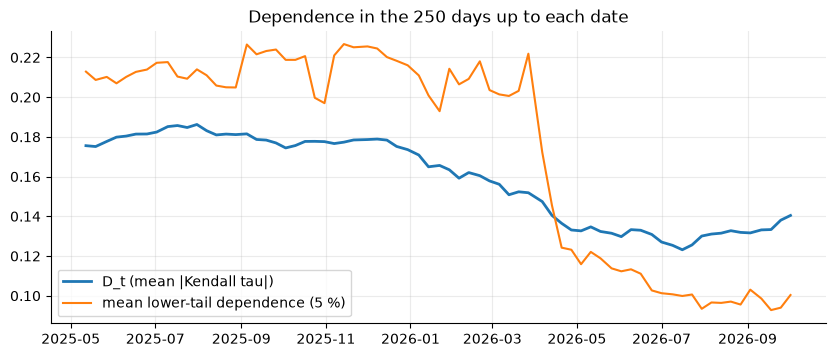

,d_t,mean_lower_tail_q,mean_upper_tail_q,tree1_edge_change,family_change_frac,bic
timestamp,,,,,,
2026-09-18,0.133,0.093,0.082,0.25,0.154,-341.854
2026-09-25,0.138,0.094,0.077,0.25,0.231,-355.182
2026-10-02,0.140,0.100,0.069,0.00,0.167,-349.552


In [7]:
from vine_risk.dependence import dependence_metrics

m = dependence_metrics(results)
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(m.index, m.d_t, lw=2, label="D_t (mean |Kendall tau|)")
ax.plot(m.index, m.mean_lower_tail_q, lw=1.5, label="mean lower-tail dependence (5 %)")
ax.legend(); ax.set_title("Dependence in the 250 days up to each date"); plt.show()
m[["d_t", "mean_lower_tail_q", "mean_upper_tail_q", "tree1_edge_change", "family_change_frac", "bic"]].tail(3).round(3)

Two things to keep in mind when you read curves like this: neighbouring dates share 249 of their 250 days, so the curve is
smooth by construction; and a change in the fitted model is not necessarily a change in the world. Notebook 4 is about
telling the two apart.

## 3.4 Data update and model refit are separate

Internally a rolling model does two different things: *pushing* a new observation into the window, and *refitting*. They are
separate methods so that other update schedules are possible, and so that the same code can run live. Below we resume the model
20 days before the end (`prime` restores a saved state without refitting), then feed the last 20 days one at a time.
`step` pushes the new observation and refits only when the schedule says so.

In [8]:
history, new_days = recent.iloc[:-20], recent.iloc[-20:]
done = [r for r in results if pd.Timestamp(r.timestamp) <= history.index[-1]]

live = RollingVineModel(window=250, refit_frequency=5, vine_kwargs=model.vine_kwargs)
live.prime(history, done)
fresh = []
for date, row in new_days.iterrows():
    out = live.step(date, row)           # None on days without a refit
    if out is not None:
        fresh.append(out)

batch = [r for r in results if pd.Timestamp(r.timestamp) > history.index[-1]]
print(f"stepwise refits: {[r.timestamp for r in fresh]}")
print("identical to the batch run:", [a.to_json() == b.to_json() for a, b in zip(fresh, batch)])

stepwise refits: ['2026-09-11', '2026-09-18', '2026-09-25', '2026-10-02']
identical to the batch run: [True, True, True, True]


Identical results, whether the data arrives all at once or day by day: this is the property that makes the
simulated live monitor of notebook 6 trustworthy.

## 3.5 Sensitivity to the window length

A shorter window reacts faster but is noisier; a longer one is smoother but slower to notice changes. The project
lets you choose freely (the PDF suggests 125, 250, 500). The same 600 days with a 125-day window:

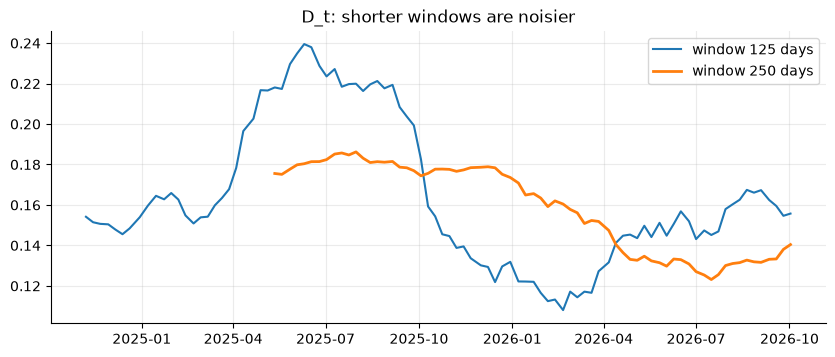

window 125: median change of D_t between fits 5 days apart: 0.0044
window 250: median change of D_t between fits 5 days apart: 0.0015


In [9]:
short = RollingVineModel(window=125, refit_frequency=5, vine_kwargs=dict(truncation_level=3, tail_simulations=4096, seed=42))
res125 = short.run(recent, n_jobs=4)
m125 = dependence_metrics(res125)
common = m125.index.intersection(m.index)          # compare the two on the same dates (both refit every 5 days)

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(m125.index, m125.d_t, lw=1.5, label="window 125 days")
ax.plot(m.index, m.d_t, lw=2, label="window 250 days")
ax.set_title("D_t: shorter windows are noisier"); ax.legend(); plt.show()
for name, d in (("125", m125), ("250", m)):
    print(f"window {name}: median change of D_t between fits 5 days apart: {d.d_t.loc[common].diff().abs().median():.4f}")

**Things to try:** a window of 500, `refit_frequency=1` (a fit every day; slower), `truncation_level=None` (full vines), or
`vine_kwargs=dict(families=["gaussian", "student"])` to restrict the building blocks.

Next: `04_dependence_changes.ipynb`, asking whether the changes you see in these curves are real.